Target: a = 0.02083
Starting simulation with 20 trials per point...
Done Q=100
Done Q=163
Done Q=268
Done Q=439
Done Q=719
Done Q=1178
Done Q=1930
Done Q=3162
Done Q=5179
Done Q=8483
Done Q=13894
Done Q=22758
Done Q=37275
Done Q=61054
Done Q=100000


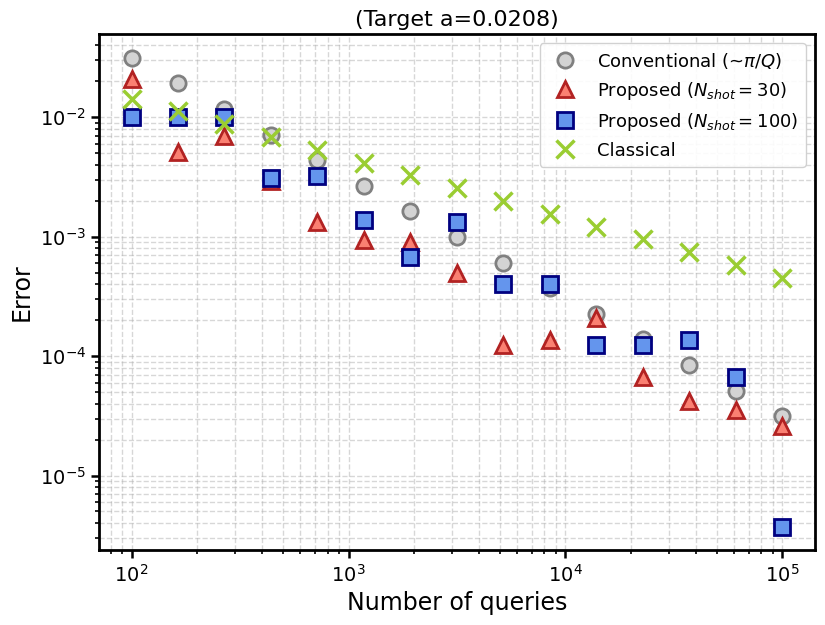

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt

# Qiskit imports
from qiskit import QuantumCircuit
from qiskit_aer.primitives import Sampler as AerSampler

# ==========================================
# 1. SETUP & CONSTANTS
# ==========================================
a_true = 1/48
theta_true = math.asin(math.sqrt(a_true))

print(f"Target: a = {a_true:.5f}")

# ==========================================
# 2. CIRCUIT HELPERS (Your setup)
# ==========================================
def build_A(theta):
    qc = QuantumCircuit(1)
    qc.ry(2*theta, 0)
    return qc

def build_Q(theta):
    # Standard Grover Operator for 1 qubit
    qc = QuantumCircuit(1)
    qc.z(0)         # S_chi
    qc.ry(-2*theta, 0) # A_dag
    qc.x(0)         # S_0
    qc.z(0)
    qc.x(0)
    qc.ry(2*theta, 0)  # A
    return qc

def get_grover_circuit(theta, k):
    qc = QuantumCircuit(1, 1)
    # A |0>
    qc.ry(2*theta, 0)
    
    # Q^k
    # We can optimize simulation by just calculating the rotation analytically 
    # if we wanted, but here we run the actual circuit to validate YOUR setup.
    if k > 0:
        # Q is effectively a rotation by 2*theta
        # k applications = rotation by k * 2*theta
        # Total state angle = (2k + 1) * theta
        # We simulate the gate structure:
        # For 1 qubit, Q is exactly a rotation around Y or Z axis depending on basis.
        # To keep it fast for simulation, we can cheat slightly or use full gates.
        # Let's use full gates but optimize the loop for speed.
        pass 
        # Actually, for 1-qubit Aer, we can just append the unitary, 
        # or rely on the fact that Q^k |psi> is predictable.
        # But let's build the real circuit to be safe.
        for _ in range(k):
             qc.z(0)
             qc.ry(-2*theta, 0)
             qc.x(0)
             qc.z(0)
             qc.x(0)
             qc.ry(2*theta, 0)
             
    qc.measure(0, 0)
    return qc

# ==========================================
# 3. CORE ALGORITHM (Suzuki Logic)
# ==========================================

def get_schedule(Q_budget, N_shot):
    """
    Greedily fills budget with exponential schedule: k = 0, 1, 2, 4, 8...
    """
    k_list = []
    
    # Always start with k=0
    current_k = 0
    
    # Calculate costs
    # Cost per experiment = N_shot * (2*k + 1)
    # We sum these up.
    
    cost_so_far = 0
    
    while True:
        # Cost of the next batch
        cost_next = N_shot * (2 * current_k + 1)
        
        if cost_so_far + cost_next <= Q_budget:
            k_list.append(current_k)
            cost_so_far += cost_next
            
            # Next k in exponential schedule
            if current_k == 0:
                current_k = 1
            else:
                current_k *= 2
        else:
            break
            
    return k_list, cost_so_far

def run_mle_estimator(Q_budget, N_shot, sampler, seed_offset):
    # 1. Get Schedule
    k_list, total_q = get_schedule(Q_budget, N_shot)
    
    if not k_list:
        return 1.0, 0 # Budget too small for even one shot
    
    # 2. Run Circuits
    # We batch them for performance
    circuits = [get_grover_circuit(theta_true, k) for k in k_list]
    
    # AerSampler is deterministic with default options unless shots imply sampling
    # We rely on the physical simulation of shots
    try:
        job = sampler.run(circuits, shots=N_shot)
        result = job.result()
    except Exception as e:
        # Fallback for older qiskit versions or primitives
        print(f"Sampler error: {e}")
        return 1.0, 0

    n1_list = []
    for i in range(len(k_list)):
        # Extract count for '1'
        dist = result.quasi_dists[i]
        # quasi_dists are probabilities, convert back to counts roughly
        count_1 = int(round(dist.get(1, 0) * N_shot))
        n1_list.append(count_1)

    # 3. MLE Post-processing
    # Grid Search Strategy
    max_k = k_list[-1]
    
    # Dynamic Grid Resolution (Crucial for high Q)
    # Period is roughly pi / (2*max_k)
    # We want ~20-50 points per period
    grid_size = max(1000, int(50 * max_k))
    
    # Cap grid size for speed (optional, but 200k is fast in numpy)
    grid_size = min(grid_size, 500_000)
    
    thetas = np.linspace(1e-7, np.pi/2 - 1e-7, grid_size)
    
    log_L = np.zeros_like(thetas)
    
    for k, n1 in zip(k_list, n1_list):
        n0 = N_shot - n1
        
        # Prob of 1 at theta for depth k
        # p = sin^2( (2k+1) * theta )
        arg = (2*k + 1) * thetas
        p = np.sin(arg)**2
        
        # Clip for numerical safety
        p = np.clip(p, 1e-15, 1-1e-15)
        
        # Log likelihood accumulation
        log_L += n1 * np.log(p) + n0 * np.log(1-p)
        
    # Find max
    best_idx = np.argmax(log_L)
    theta_est = thetas[best_idx]
    a_est = np.sin(theta_est)**2
    
    return abs(a_est - a_true), total_q

# ==========================================
# 4. EXECUTION LOOP
# ==========================================

# X-axis: Logarithmically spaced queries
queries = np.logspace(2, 5, 15).astype(int) 

# Storage
res_conventional = []
res_classical = []
res_mle_30 = []
res_mle_100 = []

# Sampler
sampler = AerSampler()

# Config
TRIALS = 20 # Increase to 50+ for smoother lines
percentile_rank = 50 # Median error (Suzuki often uses median or RMS)

print(f"Starting simulation with {TRIALS} trials per point...")

for Q in queries:
    # 1. Conventional (Theoretical Limit for Canonical QPE)
    # Error ~ pi / Q
    res_conventional.append(np.pi / Q)
    
    # 2. Classical (Theoretical or Simulated)
    # Error ~ sqrt(a(1-a)/Q)
    res_classical.append(np.sqrt(a_true*(1-a_true)/Q))
    
    # 3. Proposed MLE (N=30)
    errs_30 = []
    for t in range(TRIALS):
        e, _ = run_mle_estimator(Q, 30, sampler, t)
        errs_30.append(e)
    res_mle_30.append(np.percentile(errs_30, percentile_rank))
    
    # 4. Proposed MLE (N=100)
    errs_100 = []
    for t in range(TRIALS):
        e, _ = run_mle_estimator(Q, 100, sampler, t)
        errs_100.append(e)
    res_mle_100.append(np.percentile(errs_100, percentile_rank))
    
    print(f"Done Q={Q}")

# ==========================================
# 5. PLOTTING
# ==========================================
plt.rcParams.update({
    "font.size": 15,
    "axes.linewidth": 2.0,      # thicker graph border (spines)
})

fig, ax = plt.subplots(figsize=(8.5, 6.5))

ms = 11          # marker size
mew = 2.0        # marker edge width

ax.loglog(queries, res_conventional, 'o', color='gray',
          markerfacecolor='lightgray', markersize=ms, markeredgewidth=mew,
          label=r'Conventional (~$\pi/Q$)')

ax.loglog(queries, res_mle_30, '^', color='firebrick',
          markerfacecolor='salmon', markersize=ms, markeredgewidth=mew,
          label=r'Proposed ($N_{shot}=30$)')

ax.loglog(queries, res_mle_100, 's', color='navy',
          markerfacecolor='cornflowerblue', markersize=ms, markeredgewidth=mew,
          label=r'Proposed ($N_{shot}=100$)')

ax.loglog(queries, res_classical, 'x', color='yellowgreen',
          markersize=ms+2, markeredgewidth=mew+0.5, label='Classical')

ax.set_xlabel("Number of queries", fontsize=17)
ax.set_ylabel("Error", fontsize=17)
ax.set_title(f"(Target a={a_true:.4f})", fontsize=16)

ax.tick_params(axis='both', which='major', labelsize=14, width=1.8, length=6)
ax.tick_params(axis='both', which='minor', width=1.2, length=3)

ax.grid(True, which="both", ls="--", alpha=0.5, linewidth=1.0)
ax.legend(fontsize=13, framealpha=0.9)

fig.tight_layout()
fig.savefig("suzuki_reproduction.pdf", bbox_inches='tight')   # use this in LaTeX
fig.savefig("suzuki_reproduction.png", dpi=300, bbox_inches='tight')
plt.show()

In [13]:
# ==========================================
# 6. SLOPE CALCULATION
# ==========================================
def calculate_slope(x, y, name):
    # Filter out any zero or invalid entries just in case
    x = np.array(x)
    y = np.array(y)
    valid = (y > 0)
    
    # Fit linear model to log-log data: log(y) = m * log(x) + c
    log_x = np.log10(x[valid])
    log_y = np.log10(y[valid])
    
    # polyfit returns [slope, intercept]
    slope, intercept = np.polyfit(log_x, log_y, 1)
    
    print(f"{name} Slope: {slope:.4f}")
    return slope, intercept

print("\n=== Log-Log Slope Report ===")
calculate_slope(queries, res_conventional, "Conventional")
calculate_slope(queries, res_classical,    "Classical   ")
calculate_slope(queries, res_mle_30,       "MLE (N=30)  ")
calculate_slope(queries, res_mle_100,      "MLE (N=100) ")
print("============================\n")


=== Log-Log Slope Report ===
Conventional Slope: -1.0000
Classical    Slope: -0.5000
MLE (N=30)   Slope: -1.0055
MLE (N=100)  Slope: -1.2067

